In [1]:
import os
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
import pytorch_lightning as pl
import numpy as np
from tqdm import tqdm
import random
from random import shuffle
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from training_utils import CNN2D, spectra_stats
from training_utils import SpectraDataset_s as SpectraDataset

Seed set to 42


Seed has been set


In [2]:
# Set a fixed seed value
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
pl.seed_everything(SEED)
print("Seed has been set")

Seed set to 42


Seed has been set


# Training CNN on Spectrograms with fixed p-wave

## Data Loading

In [3]:
# Path to dataset
data_path_64 = "..\preprocessed_dset\sp_64"
data_path_32 = "..\preprocessed_dset\sp_32"
meta_path = r"..\preprocessed_dset\features_and_metadata.csv"

In [4]:
# Data stats for normalization
    
mean_64, std_64 = spectra_stats(os.path.join(data_path_64, "train"))
mean_32, std_32 = spectra_stats(os.path.join(data_path_32, "train"))

(..\preprocessed_dset\sp_64\train) Mean: [0.67176665 0.65817659 0.6412554 ], Std: [0.1186761  0.12021562 0.11939131] (calculated and saved)
(..\preprocessed_dset\sp_32\train) Mean: [0.65032865 0.63513704 0.61763785], Std: [0.12265336 0.12450042 0.12385332] (calculated and saved)


In [5]:
# Define Dataset and DataLoader

transform_64 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_64, std=std_64)
])

transform_32 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_32, std=std_32)
])

train_dset_64 = SpectraDataset(os.path.join(data_path_64, "train"), meta_path, transform_64)
train_dset_64_s = SpectraDataset(os.path.join(data_path_64, "train"), meta_path, transform_64, same_amount=True)
test_dset_64 = SpectraDataset(os.path.join(data_path_64, "test"), meta_path, transform_64, get_image_name=True)

train_dset_32 = SpectraDataset(os.path.join(data_path_32, "train"), meta_path, transform_32)
train_dset_32_s = SpectraDataset(os.path.join(data_path_32, "train"), meta_path, transform_32, same_amount=True)
test_dset_32 = SpectraDataset(os.path.join(data_path_32, "test"), meta_path, transform_32, get_image_name=True)

# print dset dimensions
print(f"Dataset 64 -> Train: {len(train_dset_64)}, Test: {len(test_dset_64)}")
print(f"Dataset 32 -> Train: {len(train_dset_32)}, Test: {len(test_dset_32)}")


# Define Test Dataloader

test_data_64 = DataLoader(test_dset_64, batch_size=32, shuffle=False)
# batches are shaped (32, 3, 33, 150)

test_data_32 = DataLoader(test_dset_32, batch_size=32, shuffle=False)
# batches are shaped (32, 3, 17, 124)


Dataset 64 -> Train: 4660, Test: 1166
Dataset 32 -> Train: 4660, Test: 1166


In [6]:
img_shape_32 = None
all_same_shape = True
different_shapes = []
for image, _ in train_dset_32:
    if not img_shape_32:
        img_shape_32 = image.shape
    if image.shape != img_shape_32:
        all_same_shape = False
        different_shapes.append(image.shape)

if all_same_shape:
    print(f"Images have the same shape: {img_shape_32}")
else:
    print(f"Original shape: {img_shape_32}")
    print(f"Images have different shapes: {different_shapes}")
    
    

Images have the same shape: torch.Size([3, 17, 124])


In [7]:
img_shape_64 = None
all_same_shape = True
different_shapes = []
for image, _ in train_dset_64:
    if not img_shape_64:
        img_shape_64 = image.shape
    if image.shape != img_shape_64:
        all_same_shape = False
        different_shapes.append(image.shape)

if all_same_shape:
    print(f"Images have the same shape: {img_shape_64}")
else:
    print(f"Original shape: {img_shape_64}")
    print(f"Images have different shapes: {different_shapes}")

Images have the same shape: torch.Size([3, 33, 150])


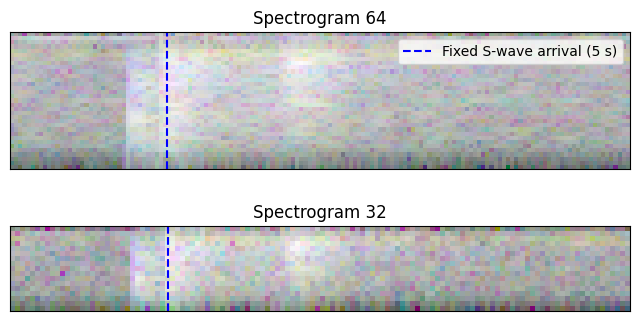

In [8]:
import matplotlib.pyplot as plt

# Get one sample image from each test dataset (they return image, label, img_name)
image_64, _, _ = test_dset_64[0]
image_32, _, _ = test_dset_32[0]

# Convert torch tensors (C, H, W) to numpy arrays (H, W, C)
img_np_64 = image_64.permute(1, 2, 0).numpy()
img_np_32 = image_32.permute(1, 2, 0).numpy()

img_np_64 = (img_np_64 - img_np_64.min()) / (img_np_64.max() - img_np_64.min())
img_np_32 = (img_np_32 - img_np_32.min()) / (img_np_32.max() - img_np_32.min())

# Calculate pixels per second: each image has been cropped to 20 seconds.
pps_64 = img_np_64.shape[1] / 20  # width/20 for dataset 64
pps_32 = img_np_32.shape[1] / 20  # width/20 for dataset 32

# Compute vertical line positions (5 seconds)
line_x_64 = 5 * pps_64
line_x_32 = 5 * pps_32

# Create a vertical subplot with 2 rows
fig, axes = plt.subplots(2, 1, figsize=(8, 4))

# Plot image from Spectrogram 64
axes[0].imshow(img_np_64)
axes[0].axvline(x=line_x_64, color='blue', linestyle='--', label='Fixed S-wave arrival (5 s)')
axes[0].set_title('Spectrogram 64')
axes[0].legend()
axes[0].get_xaxis().set_visible(False)
axes[0].get_yaxis().set_visible(False)


# Plot image from Spectrogram 32
axes[1].imshow(img_np_32)
axes[1].axvline(x=line_x_32, color='blue', linestyle='--')
axes[1].set_title('Spectrogram 32')
axes[1].get_xaxis().set_visible(False)
axes[1].get_yaxis().set_visible(False)


plt.show()

In [9]:
def split_train_cross_val(dataset, n_splits=7):
    splits = []
    size = (len(dataset) // n_splits)
    last_size = len(dataset) - size*(n_splits-1)
    out = random_split(dataset, [size]*(n_splits - 1) + [last_size])
    for idx in range(n_splits):
        train = torch.utils.data.ConcatDataset([out[i] for i in range(n_splits) if i != idx])
        val = out[idx]
        splits.append((train, val))
        print(f"Split {idx}: Train: {len(train)}, Val: {len(val)}")
    print()
    return splits

splits_64 = split_train_cross_val(train_dset_64)
splits_64_s = split_train_cross_val(train_dset_64_s)
splits_32 = split_train_cross_val(train_dset_32)
splits_32_s = split_train_cross_val(train_dset_32_s)

Split 0: Train: 3995, Val: 665
Split 1: Train: 3995, Val: 665
Split 2: Train: 3995, Val: 665
Split 3: Train: 3995, Val: 665
Split 4: Train: 3995, Val: 665
Split 5: Train: 3995, Val: 665
Split 6: Train: 3990, Val: 670

Split 0: Train: 3004, Val: 500
Split 1: Train: 3004, Val: 500
Split 2: Train: 3004, Val: 500
Split 3: Train: 3004, Val: 500
Split 4: Train: 3004, Val: 500
Split 5: Train: 3004, Val: 500
Split 6: Train: 3000, Val: 504

Split 0: Train: 3995, Val: 665
Split 1: Train: 3995, Val: 665
Split 2: Train: 3995, Val: 665
Split 3: Train: 3995, Val: 665
Split 4: Train: 3995, Val: 665
Split 5: Train: 3995, Val: 665
Split 6: Train: 3990, Val: 670

Split 0: Train: 3004, Val: 500
Split 1: Train: 3004, Val: 500
Split 2: Train: 3004, Val: 500
Split 3: Train: 3004, Val: 500
Split 4: Train: 3004, Val: 500
Split 5: Train: 3004, Val: 500
Split 6: Train: 3000, Val: 504



In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Training

In [17]:
best_model_64_accuracy = 0
best_model_64_path = None

for idx, (train_dset, val_dset) in enumerate(splits_64):
    model = CNN2D(input_dim=img_shape_64[-2:])
    
    print(f"Training model for fold {idx}...")
    early_stop_callback = EarlyStopping(monitor='val_acc', patience=3, mode='max')
    checkpoint_callback = ModelCheckpoint(monitor='val_acc', mode='max', save_top_k=1, dirpath='s_wave_model_checkpoints/model_checkpoints_64', filename=f'best_model_fold_{idx}')
    
    trainer = pl.Trainer(
        max_epochs=10, 
        accelerator='gpu',
        devices=-1, 
        callbacks=[early_stop_callback, checkpoint_callback],
        enable_model_summary = (False if idx > 0 else True)
    )
    
    trainer.fit(model, DataLoader(train_dset, batch_size=32, shuffle=True), DataLoader(val_dset, batch_size=32, shuffle=False))
    
    val_acc = trainer.callback_metrics.get('val_acc', 0).item()  # Extract validation accuracy
    
    if val_acc > best_model_64_accuracy:
        best_model_64_accuracy = val_acc
        best_model_64_path = checkpoint_callback.best_model_path
        print(f"New best model found for fold {idx} with valid accuracy: {val_acc:.4f}")


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\miche\OneDrive\Desktop\EQML Project\CNN-Explainability-on-Earthquakes\CNN_EQML\Lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training model for fold 0...



   | Name       | Type             | Params | Mode 
---------------------------------------------------------
0  | conv1      | Conv2d           | 896    | train
1  | BatchNorm1 | BatchNorm2d      | 64     | train
2  | conv2      | Conv2d           | 18.5 K | train
3  | BatchNorm2 | BatchNorm2d      | 128    | train
4  | conv3      | Conv2d           | 73.9 K | train
5  | BatchNorm3 | BatchNorm2d      | 256    | train
6  | maxpool    | MaxPool2d        | 0      | train
7  | relu       | ReLU             | 0      | train
8  | dropout    | Dropout          | 0      | train
9  | flatten    | Flatten          | 0      | train
10 | fc1        | Linear           | 4.8 M  | train
11 | fc2        | Linear           | 258    | train
12 | criterion  | CrossEntropyLoss | 0      | train
---------------------------------------------------------
4.9 M     Trainable params
0         Non-trainable params
4.9 M     Total params
19.775    Total estimated model params size (MB)
13        Modules in trai

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\miche\OneDrive\Desktop\EQML Project\CNN-Explainability-on-Earthquakes\CNN_EQML\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


...

Training model for fold 5...


TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 4: 100%|██████████| 125/125 [00:26<00:00,  4.72it/s, v_num=19, train_loss=0.137, val_loss=0.0184, val_acc=0.995]    


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training model for fold 6...
Epoch 4: 100%|██████████| 125/125 [00:23<00:00,  5.41it/s, v_num=20, train_loss=2.99e-6, val_loss=0.0289, val_acc=0.997] 


In [18]:
best_model_64_accuracy = 0
best_model_64_path_s = None

for idx, (train_dset, val_dset) in enumerate(splits_64_s):
    model = CNN2D(input_dim=img_shape_64[-2:])
    
    print(f"Training model for fold {idx}...")
    early_stop_callback = EarlyStopping(monitor='val_acc', patience=3, mode='max')
    checkpoint_callback = ModelCheckpoint(monitor='val_acc', mode='max', save_top_k=1, dirpath='s_wave_model_checkpoints/model_checkpoints_64_s', filename=f'best_model_fold_{idx}')
    
    trainer = pl.Trainer(
        max_epochs=10, 
        accelerator='gpu',
        devices=-1, 
        callbacks=[early_stop_callback, checkpoint_callback],
        enable_model_summary = (False if idx > 0 else True)
    )
    
    trainer.fit(model, DataLoader(train_dset, batch_size=32, shuffle=True), DataLoader(val_dset, batch_size=32, shuffle=False))
    
    val_acc = trainer.callback_metrics.get('val_acc', 0).item()  # Extract validation accuracy
    
    if val_acc > best_model_64_accuracy:
        best_model_64_accuracy = val_acc
        best_model_64_path_s = checkpoint_callback.best_model_path
        print(f"New best model found for fold {idx} with valid accuracy: {val_acc:.4f}")


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name       | Type             | Params | Mode 
---------------------------------------------------------
0  | conv1      | Conv2d           | 896    | train
1  | BatchNorm1 | BatchNorm2d      | 64     | train
2  | conv2      | Conv2d           | 18.5 K | train
3  | BatchNorm2 | BatchNorm2d      | 128    | train
4  | conv3      | Conv2d           | 73.9 K | train
5  | BatchNorm3 | BatchNorm2d      | 256    | train
6  | maxpool    | MaxPool2d        | 0      | train
7  | relu       | ReLU             | 0      | train
8  | dropout    | Dropout          | 0      | train
9  | flatten    | Flatten          | 0      | train
10 | fc1        | Linear           | 4.8 M  | train
11 | fc2        | Linear           | 258    | train
12 | criterion  | CrossEntropyLoss | 0      | train
-------------------------------------------------------

Training model for fold 0...
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\miche\OneDrive\Desktop\EQML Project\CNN-Explainability-on-Earthquakes\CNN_EQML\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


c:\Users\miche\OneDrive\Desktop\EQML Project\CNN-Explainability-on-Earthquakes\CNN_EQML\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch 5: 100%|██████████| 94/94 [00:17<00:00,  5.28it/s, v_num=21, train_loss=4.77e-5, val_loss=0.0067, val_acc=0.996]  
New best model found for fold 0 with valid accuracy: 0.9960
Training model for fold 1...


...

Training model for fold 4...
Epoch 8: 100%|██████████| 94/94 [00:28<00:00,  3.30it/s, v_num=25, train_loss=8.61e-5, val_loss=0.00432, val_acc=0.998] 


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training model for fold 5...
Epoch 6: 100%|██████████| 94/94 [00:16<00:00,  5.85it/s, v_num=26, train_loss=0.00248, val_loss=0.0344, val_acc=0.996] 


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training model for fold 6...
Epoch 5: 100%|██████████| 94/94 [00:16<00:00,  5.67it/s, v_num=27, train_loss=0.0346, val_loss=0.019, val_acc=0.996]   


In [19]:
best_model_32_accuracy = 0
best_model_32_path = None

for idx, (train_dset, val_dset) in enumerate(splits_32):
    model = CNN2D(input_dim=img_shape_32[-2:])
    
    print(f"Training model for fold {idx}...")
    early_stop_callback = EarlyStopping(monitor='val_acc', patience=3, mode='max')
    checkpoint_callback = ModelCheckpoint(monitor='val_acc', mode='max', save_top_k=1, dirpath='s_wave_model_checkpoints/model_checkpoints_32', filename=f'best_model_fold_{idx}')
    
    trainer = pl.Trainer(
        max_epochs=10, 
        accelerator='gpu',
        devices=-1, 
        callbacks=[early_stop_callback, checkpoint_callback],
        enable_model_summary = (False if idx > 0 else True)
    )
    
    trainer.fit(model, DataLoader(train_dset, batch_size=32, shuffle=True), DataLoader(val_dset, batch_size=32, shuffle=False))
    
    val_acc = trainer.callback_metrics.get('val_acc', 0).item()  # Extract validation accuracy
    
    if val_acc > best_model_32_accuracy:
        best_model_32_accuracy = val_acc
        best_model_32_path = checkpoint_callback.best_model_path
        print(f"New best model found for fold {idx} with valid accuracy: {val_acc:.4f}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Training model for fold 0...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name       | Type             | Params | Mode 
---------------------------------------------------------
0  | conv1      | Conv2d           | 896    | train
1  | BatchNorm1 | BatchNorm2d      | 64     | train
2  | conv2      | Conv2d           | 18.5 K | train
3  | BatchNorm2 | BatchNorm2d      | 128    | train
4  | conv3      | Conv2d           | 73.9 K | train
5  | BatchNorm3 | BatchNorm2d      | 256    | train
6  | maxpool    | MaxPool2d        | 0      | train
7  | relu       | ReLU             | 0      | train
8  | dropout    | Dropout          | 0      | train
9  | flatten    | Flatten          | 0      | train
10 | fc1        | Linear           | 2.0 M  | train
11 | fc2        | Linear           | 258    | train
12 | criterion  | CrossEntropyLoss | 0      | train
---------------------------------------------------------
2.1 M     Trainable params
0         Non-trainable params
2.1 M     Total params
8.503     Total estimated model 

Epoch 8: 100%|██████████| 125/125 [00:18<00:00,  6.91it/s, v_num=28, train_loss=4.4e-5, val_loss=0.0272, val_acc=0.994]  
New best model found for fold 0 with valid accuracy: 0.9940


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\miche\OneDrive\Desktop\EQML Project\CNN-Explainability-on-Earthquakes\CNN_EQML\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:654: Checkpoint directory C:\Users\miche\OneDrive\Desktop\EQML Project\CNN-Explainability-on-Earthquakes\training\s_wave_model_checkpoints\model_checkpoints_32 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Training model for fold 6...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 9: 100%|██████████| 125/125 [00:21<00:00,  5.90it/s, v_num=34, train_loss=2.13e-5, val_loss=0.0562, val_acc=0.994] 

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 125/125 [00:21<00:00,  5.90it/s, v_num=34, train_loss=2.13e-5, val_loss=0.0562, val_acc=0.994]


In [20]:
best_model_32_accuracy = 0
best_model_32_path_s = None

for idx, (train_dset, val_dset) in enumerate(splits_32):
    model = CNN2D(input_dim=img_shape_32[-2:])
    
    print(f"Training model for fold {idx}...")
    early_stop_callback = EarlyStopping(monitor='val_acc', patience=3, mode='max')
    checkpoint_callback = ModelCheckpoint(monitor='val_acc', mode='max', save_top_k=1, dirpath='s_wave_model_checkpoints/model_checkpoints_32_s', filename=f'best_model_fold_{idx}')
    
    trainer = pl.Trainer(
        max_epochs=10, 
        accelerator='gpu',
        devices=-1, 
        callbacks=[early_stop_callback, checkpoint_callback],
        enable_model_summary = (False if idx > 0 else True)
    )
    
    trainer.fit(model, DataLoader(train_dset, batch_size=32, shuffle=True), DataLoader(val_dset, batch_size=32, shuffle=False))
    
    val_acc = trainer.callback_metrics.get('val_acc', 0).item()  # Extract validation accuracy
    
    if val_acc > best_model_32_accuracy:
        best_model_32_accuracy = val_acc
        best_model_32_path_s = checkpoint_callback.best_model_path
        print(f"New best model found for fold {idx} with valid accuracy: {val_acc:.4f}")

Training model for fold 0...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name       | Type             | Params | Mode 
---------------------------------------------------------
0  | conv1      | Conv2d           | 896    | train
1  | BatchNorm1 | BatchNorm2d      | 64     | train
2  | conv2      | Conv2d           | 18.5 K | train
3  | BatchNorm2 | BatchNorm2d      | 128    | train
4  | conv3      | Conv2d           | 73.9 K | train
5  | BatchNorm3 | BatchNorm2d      | 256    | train
6  | maxpool    | MaxPool2d        | 0      | train
7  | relu       | ReLU             | 0      | train
8  | dropout    | Dropout          | 0      | train
9  | flatten    | Flatten          | 0      | train
10 | fc1        | Linear           | 2.0 M  | train
11 | fc2        | Linear           | 258    | train
12 | criterion  | CrossEntropyLoss | 0      | train
-------------------------------------------------------

Epoch 3: 100%|██████████| 125/125 [00:21<00:00,  5.93it/s, v_num=35, train_loss=0.00314, val_loss=0.0468, val_acc=0.988] 
New best model found for fold 0 with valid accuracy: 0.9880
Training model for fold 1...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\miche\OneDrive\Desktop\EQML Project\CNN-Explainability-on-Earthquakes\CNN_EQML\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:654: Checkpoint directory C:\Users\miche\OneDrive\Desktop\EQML Project\CNN-Explainability-on-Earthquakes\training\s_wave_model_checkpoints\model_checkpoints_32_s exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 5: 100%|██████████| 125/125 [00:19<00:00,  6.31it/s, v_num=36, train_loss=0.000311, val_loss=0.0904, val_acc=0.965]


...


Training model for fold 5...


TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 6: 100%|██████████| 125/125 [00:19<00:00,  6.31it/s, v_num=40, train_loss=0.000417, val_loss=0.0783, val_acc=0.980]
Training model for fold 6...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 6: 100%|██████████| 125/125 [00:29<00:00,  4.29it/s, v_num=41, train_loss=3.18e-5, val_loss=0.0597, val_acc=0.988] 


In [21]:
print(f"Best model for Spectra 64 dataset: {best_model_64_path}")
print(f"Best model for Spectra 64 dataset (same amount): {best_model_64_path_s}")
print(f"Best model for Spectra 32 dataset: {best_model_32_path}")
print(f"Best model for Spectra 32 dataset (same amount): {best_model_32_path_s}")

Best model for Spectra 64 dataset: C:\Users\miche\OneDrive\Desktop\EQML Project\CNN-Explainability-on-Earthquakes\training\s_wave_model_checkpoints\model_checkpoints_64\best_model_fold_0.ckpt
Best model for Spectra 64 dataset (same amount): C:\Users\miche\OneDrive\Desktop\EQML Project\CNN-Explainability-on-Earthquakes\training\s_wave_model_checkpoints\model_checkpoints_64_s\best_model_fold_3.ckpt
Best model for Spectra 32 dataset: C:\Users\miche\OneDrive\Desktop\EQML Project\CNN-Explainability-on-Earthquakes\training\s_wave_model_checkpoints\model_checkpoints_32\best_model_fold_2.ckpt
Best model for Spectra 32 dataset (same amount): C:\Users\miche\OneDrive\Desktop\EQML Project\CNN-Explainability-on-Earthquakes\training\s_wave_model_checkpoints\model_checkpoints_32_s\best_model_fold_2.ckpt


## Metrics on Test Set

In [11]:
#Already runned models
best_model_64_path = "s_wave_model_checkpoints/model_checkpoints_64/best_model_fold.ckpt"
best_model_64_path_s = "s_wave_model_checkpoints/model_checkpoints_64/best_model_fold_s.ckpt"
best_model_32_path = "s_wave_model_checkpoints/model_checkpoints_32/best_model_fold.ckpt"
best_model_32_path_s = "s_wave_model_checkpoints/model_checkpoints_32/best_model_fold_s.ckpt"

In [12]:
def compute_test_metrics(model_path, test_dset, input_dim):
    model = CNN2D.load_from_checkpoint(model_path, input_dim=input_dim, n_classes=2)
    trainer = pl.Trainer(enable_model_summary=False, logger=False, enable_progress_bar=False)
    trainer.test(model, test_dset)

Testing Metrics for Spectrogram 64 dataset:


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\miche\OneDrive\Desktop\EQML Project\CNN-Explainability-on-Earthquakes\CNN_EQML\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


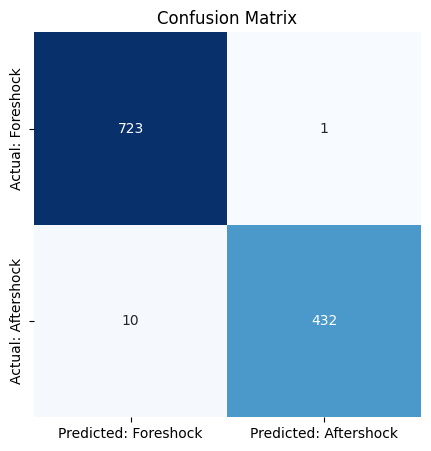

Total Accuracy: 0.9906
Total Precision: 0.9977
Total Recall: 0.9774
Total F1 Score: 0.9874
Testing Metrics for Spectrogram 64 dataset (with same amount of data for each class):


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\miche\OneDrive\Desktop\EQML Project\CNN-Explainability-on-Earthquakes\CNN_EQML\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


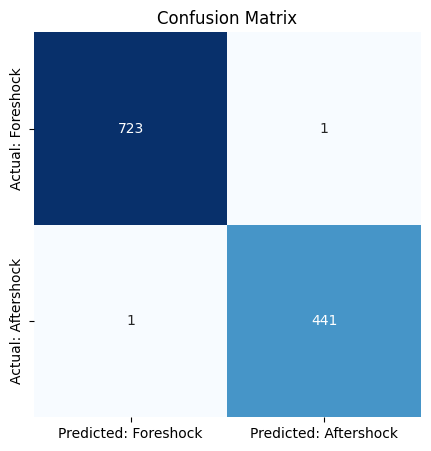

Total Accuracy: 0.9983
Total Precision: 0.9977
Total Recall: 0.9977
Total F1 Score: 0.9977


In [13]:
print("Testing Metrics for Spectrogram 64 dataset:")
compute_test_metrics(best_model_64_path, test_data_64, input_dim=img_shape_64[-2:])

print("Testing Metrics for Spectrogram 64 dataset (with same amount of data for each class):")
compute_test_metrics(best_model_64_path_s, test_data_64, input_dim=img_shape_64[-2:])

Testing Metrics for Spectrogram 32 dataset:


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\miche\OneDrive\Desktop\EQML Project\CNN-Explainability-on-Earthquakes\CNN_EQML\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


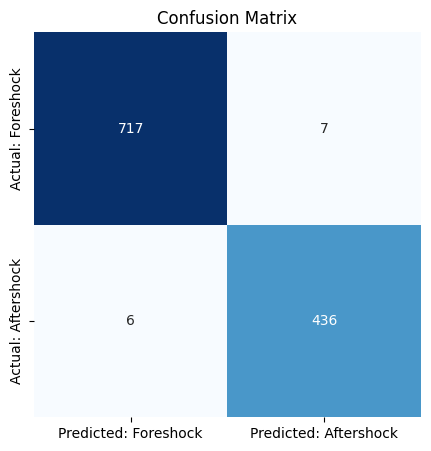

Total Accuracy: 0.9889
Total Precision: 0.9842
Total Recall: 0.9864
Total F1 Score: 0.9853
Testing Metrics for Spectrogram 32 dataset (with same amount of data for each class):


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\miche\OneDrive\Desktop\EQML Project\CNN-Explainability-on-Earthquakes\CNN_EQML\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


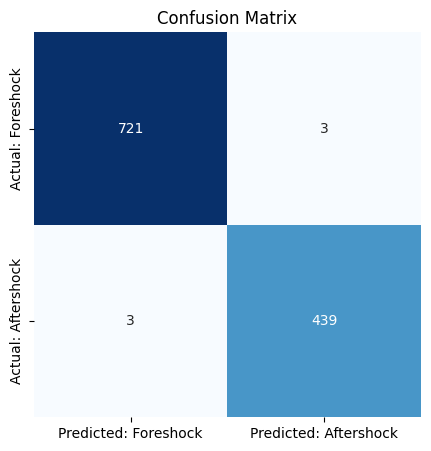

Total Accuracy: 0.9949
Total Precision: 0.9932
Total Recall: 0.9932
Total F1 Score: 0.9932


In [14]:
print("Testing Metrics for Spectrogram 32 dataset:")
compute_test_metrics(best_model_32_path, test_data_32, input_dim=img_shape_32[-2:])

print("Testing Metrics for Spectrogram 32 dataset (with same amount of data for each class):")
compute_test_metrics(best_model_32_path_s, test_data_32, input_dim=img_shape_32[-2:])

## Preparing Test Dataset for Explainability


In [16]:
pick = 300 # Number of correct predicted random samples to pick for each class
correct_aftershock_samples = []
correct_foreschock_samples = []

model = CNN2D.load_from_checkpoint(best_model_64_path_s, input_dim=img_shape_64[-2:], n_classes=2)
model.eval()
model.to(device)

for img, label, img_name in tqdm(test_data_64, desc="Checking correct samples"):
    img = img.to(device)
    label = label.to(device)
    output = model(img)
    _, predicted = torch.max(output, 1)
    correct = (predicted == label).squeeze()
    for i in range(len(correct)):
        if correct[i]:
            if label[i] == 1:
                correct_aftershock_samples.append(img_name[i])
            else:
                correct_foreschock_samples.append(img_name[i])

    if len(correct_aftershock_samples) >= pick and len(correct_foreschock_samples) >= pick:
        break

shuffle(correct_aftershock_samples)
shuffle(correct_foreschock_samples)
correct_aftershock_samples = correct_aftershock_samples[:pick]
correct_foreschock_samples = correct_foreschock_samples[:pick]

print(f"Correct aftershock samples: {len(correct_aftershock_samples)}")
print(f"Correct foreschock samples: {len(correct_foreschock_samples)}")


output_explain_path = os.path.join(data_path_64, "explainer_s_wave", "aftershock")
os.makedirs(output_explain_path, exist_ok=True)
for name in tqdm(correct_aftershock_samples, desc="Copying aftershock samples"):
    img_path = os.path.join(data_path_64, "test", name + "_post.png")
    
    # Copy and Paste the image to the output folder
    os.system(f"copy {img_path} {output_explain_path}")

output_explain_path = os.path.join(data_path_64, "explainer_s_wave", "foreshock")
os.makedirs(output_explain_path, exist_ok=True)
for name in tqdm(correct_foreschock_samples, desc="Copying foreschock samples"):
    img_path = os.path.join(data_path_64, "test", name + "_pre.png")
    
    # Copy and Paste the image to the output folder
    os.system(f"copy {img_path} {output_explain_path}")

Checking correct samples:  62%|██████▏   | 23/37 [00:05<00:03,  4.17it/s]


Correct aftershock samples: 300
Correct foreschock samples: 300


Copying foreschock samples: 100%|██████████| 300/300 [00:12<00:00, 24.25it/s]


In [17]:
pick = 300 # Number of correct predicted random samples to pick for each class
correct_aftershock_samples = []
correct_foreschock_samples = []

model = CNN2D.load_from_checkpoint(best_model_32_path_s, input_dim=img_shape_32[-2:], n_classes=2)
model.eval()
model.to(device)

for img, label, img_name in tqdm(test_data_32, desc="Checking correct samples"):
    img = img.to(device)
    label = label.to(device)
    output = model(img)
    _, predicted = torch.max(output, 1)
    correct = (predicted == label).squeeze()
    for i in range(len(correct)):
        if correct[i]:
            if label[i] == 1:
                correct_aftershock_samples.append(img_name[i])
            else:
                correct_foreschock_samples.append(img_name[i])

    if len(correct_aftershock_samples) >= pick and len(correct_foreschock_samples) >= pick:
        break

shuffle(correct_aftershock_samples)
shuffle(correct_foreschock_samples)
correct_aftershock_samples = correct_aftershock_samples[:pick]
correct_foreschock_samples = correct_foreschock_samples[:pick]

print(f"Correct aftershock samples: {len(correct_aftershock_samples)}")
print(f"Correct foreschock samples: {len(correct_foreschock_samples)}")

output_explain_path = os.path.join(data_path_32, "explainer_s_wave", "aftershock")
os.makedirs(output_explain_path, exist_ok=True)
for name in tqdm(correct_aftershock_samples, desc="Copying aftershock samples"):
    img_path = os.path.join(data_path_32, "test", name + "_post.png")
    
    # Copy and Paste the image to the output folder
    os.system(f"copy {img_path} {output_explain_path}")

output_explain_path = os.path.join(data_path_32, "explainer_s_wave", "foreshock")
os.makedirs(output_explain_path, exist_ok=True)
for name in tqdm(correct_foreschock_samples, desc="Copying foreschock samples"):
    img_path = os.path.join(data_path_32, "test", name + "_pre.png")
    
    # Copy and Paste the image to the output folder
    os.system(f"copy {img_path} {output_explain_path}")

Checking correct samples:  62%|██████▏   | 23/37 [00:04<00:02,  5.05it/s]


Correct aftershock samples: 300
Correct foreschock samples: 300


Copying foreschock samples: 100%|██████████| 300/300 [00:14<00:00, 21.36it/s]
